In [163]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
import pandas as pd
import functions
from google.cloud import bigquery
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [166]:
client = bigquery.Client()

In [167]:
mart_apps_summary = f"""
SELECT *
FROM `{config['tables']['mart_apps_summary']}`
"""
df = client.query(mart_apps_summary).to_dataframe()

# sentiment_df = df[df["avg_sentiment"].notna()]

In [168]:
# Dataset Overview
display(df.shape)
print()
display(df.info())
print()
display(df.isnull().sum())
print()
display(df.describe())

(9659, 11)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   app                  9659 non-null   object 
 1   category             9659 non-null   object 
 2   app_type             9658 non-null   object 
 3   rating               8196 non-null   float64
 4   installs             9659 non-null   Int64  
 5   price                9659 non-null   float64
 6   total_reviews        9659 non-null   Int64  
 7   sample_review_count  816 non-null    Int64  
 8   avg_sentiment        816 non-null    float64
 9   positive_review_pct  816 non-null    float64
 10  is_paid              9659 non-null   boolean
dtypes: Int64(3), boolean(1), float64(4), object(3)
memory usage: 801.9+ KB


None

app                       0
category                  0
app_type                  1
rating                 1463
installs                  0
price                     0
total_reviews             0
sample_review_count    8843
avg_sentiment          8843
positive_review_pct    8843
is_paid                   0
dtype: int64

,rating,installs,price,total_reviews,sample_review_count,avg_sentiment,positive_review_pct
count,8196.000000,9659.0,9659.000000,9659.0,816.0,816.000000,816.000000
mean,4.173267,7798170.248162,1.097231,216804.110363,44.030637,0.200519,0.647158
std,0.536253,53769728.818071,16.851618,1831430.21321,37.878823,0.161432,0.183044
min,1.000000,0.0,0.000000,0.0,1.0,-0.500000,0.000000
25%,4.000000,1000.0,0.000000,25.0,28.0,0.082372,0.538462
50%,4.300000,100000.0,0.000000,969.0,37.0,0.198221,0.666667
75%,4.500000,1000000.0,0.000000,29453.5,40.0,0.299261,0.769231
max,5.000000,1000000000.0,400.000000,78158306.0,312.0,1.000000,1.000000


In [169]:
# ==================================================================================================================================
# Data Integration Limitation
# - Approximately 94% of applications in the review dataset were successfully matched with the app metadata table.
# - A small subset of applications could not be linked due to inconsistencies in app naming conventions across the original datasets.
# 
# Insights
# 1.App installs are highly right-skewed, with a small number 
# of applications accounting for a disproportionately large share of total downloads.
# 
# 2.User ratings are heavily concentrated between 4.0 and 4.5, 
# indicating generally positive evaluations across most applications.
# 
# 3.The app marketplace is overwhelmingly dominated by free applications, 
# while paid apps form a small long-tail segment with highly variable pricing.
# 
# hypothesis 1 : free apps have high installs
# hypothesis 2 : apps with high installs might not have better sentiment
# hypothesis 3 : certain apps, such as Education and Health apps, have higher sentiment
# ==================================================================================================================================

In [170]:
# ==================================================================================================================================
# Distribution Analysis
# ==================================================================================================================================

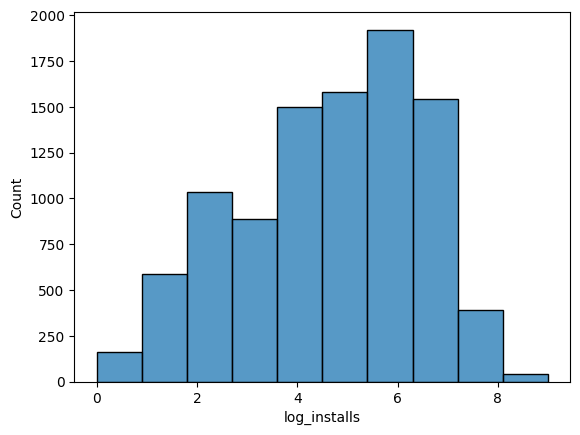

In [171]:
df["log_installs"] = np.log10(df["installs"] + 1)

sns.histplot(df["log_installs"], bins=10)

plt.savefig(
    f"{config['output_data']['charts']}distribution_log_installs.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [172]:
# App installs exhibit a highly discrete and right-skewed distribution, reflecting 
# the bucketed install ranges used by the Google Play Store. 
# Most applications cluster within lower-to-mid download tiers, while only a small subset achieves massive adoption.

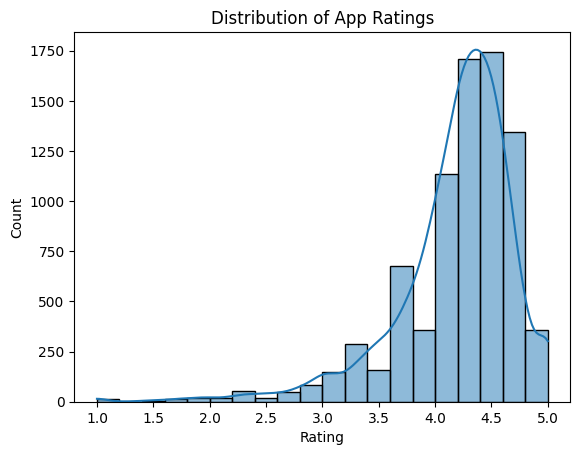

In [173]:
sns.histplot(df["rating"], bins=20, kde=True)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of App Ratings")

plt.savefig(
    f"{config['output_data']['charts']}distribution_app_ratings.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [174]:
# Distribution of App Ratings
# App ratings are strongly concentrated in the upper range, with most applications receiving scores between 4.0 and 4.5.
# The distribution is left-skewed, indicating that poorly rated applications are relatively rare within the dataset.
# This limited variance suggests that ratings alone may not fully explain differences in app popularity or install volume.

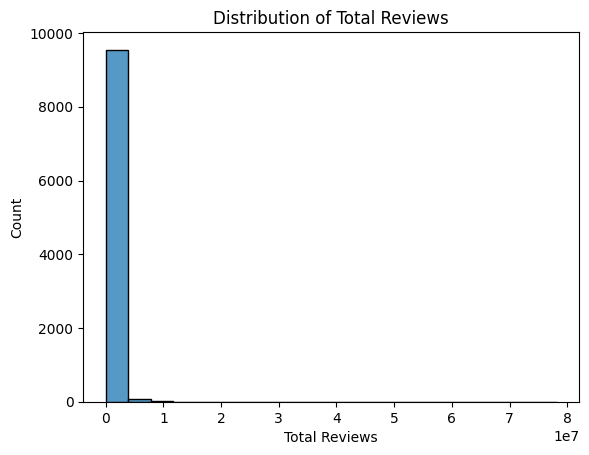

In [175]:
sns.histplot(df["total_reviews"], bins=20)

plt.xlabel("Total Reviews")
plt.ylabel("Count")
plt.title("Distribution of Total Reviews")

plt.show()

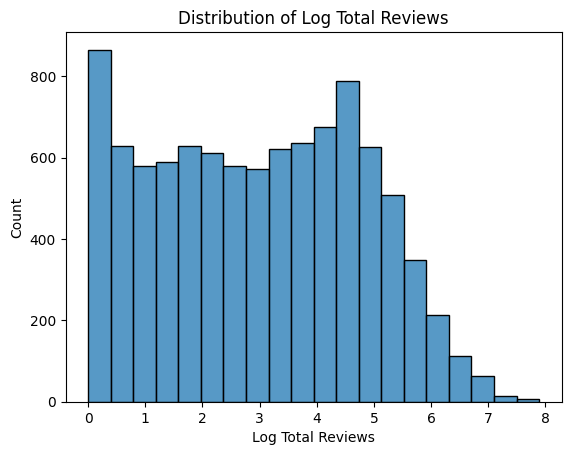

In [176]:
df["log_total_reviews"] = np.log10(df["total_reviews"] + 1)
sns.histplot(df["log_total_reviews"], bins=20)

plt.xlabel("Log Total Reviews")
plt.ylabel("Count")
plt.title("Distribution of Log Total Reviews")

plt.savefig(
    f"{config['output_data']['charts']}distribution_log_total_review_count.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [177]:
# Review activity is unevenly distributed across applications, with most apps receiving relatively few
# sampled reviews while a smaller subset generates substantially higher engagement.
# After log transformation, the review count distribution becomes more interpretable, revealing a concentration
# of applications within moderate engagement levels.

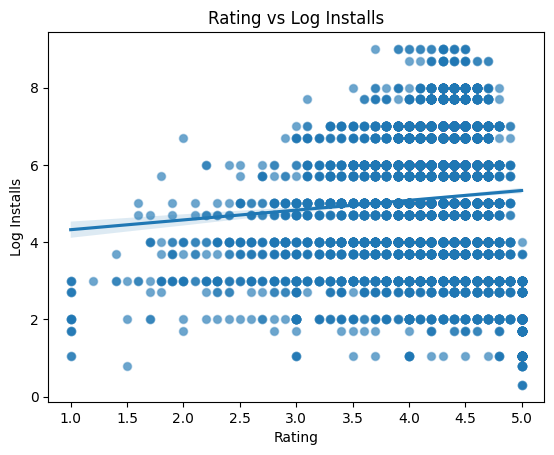

In [178]:
sns.scatterplot(
    data=df,
    x="rating",
    y="log_installs",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="rating",
    y="log_installs",
    scatter_kws={"alpha":0.3}
)

plt.xlabel("Rating")
plt.ylabel("Log Installs")
plt.title("Rating vs Log Installs")

plt.savefig(
    f"{config['output_data']['charts']}distribution_rating_vs_log_installs.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [179]:
# Rating vs Installs
# Although higher-rated applications tend to achieve slightly greater install volumes on average, the relationship appears relatively weak. 
# Applications with similar ratings can exhibit dramatically different adoption levels, suggesting that 
# factors beyond user ratings play a major role in app popularity.

In [180]:
# ==================================================================================================================================
# Free vs Paid
# ==================================================================================================================================

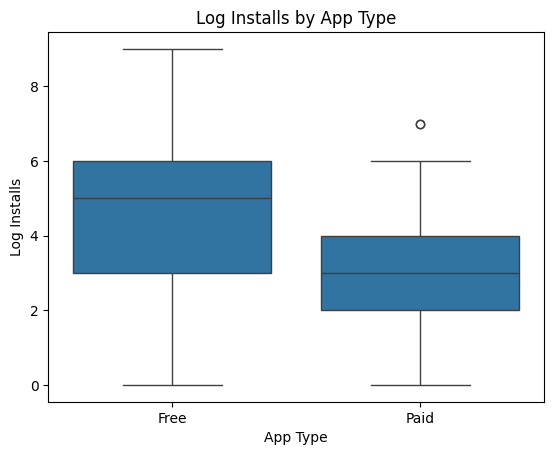

In [181]:
sns.boxplot(
    data=df,
    x="app_type",
    y="log_installs"
)

plt.xlabel("App Type")
plt.ylabel("Log Installs")
plt.title("Log Installs by App Type")

plt.savefig(
    f"{config['output_data']['charts']}freevspaid_log_installs_by_apptype.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

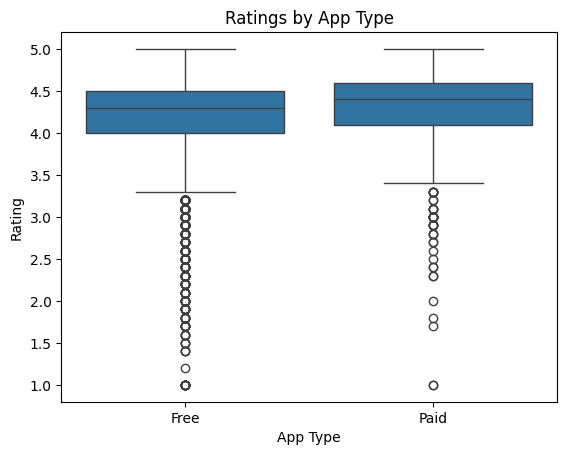

In [182]:
sns.boxplot(
    data=df,
    x="app_type",
    y="rating"
)

plt.xlabel("App Type")
plt.ylabel("Rating")
plt.title("Ratings by App Type")

plt.savefig(
    f"{config['output_data']['charts']}freevspaid_ratings_by_apptype.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

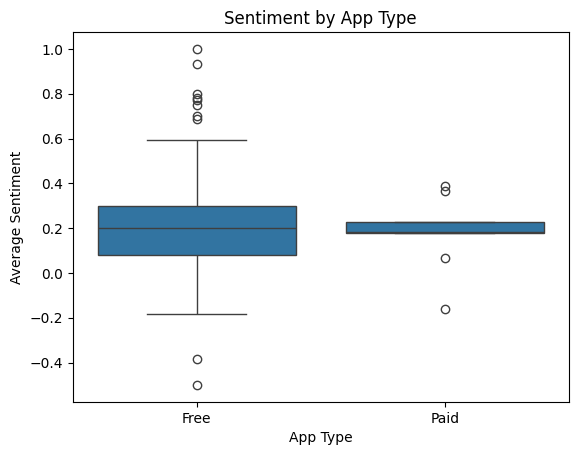

In [195]:
sentiment_df = df[df["avg_sentiment"].notna()].copy()

sns.boxplot(
    data=sentiment_df,
    x="app_type",
    y="avg_sentiment"
)

plt.xlabel("App Type")
plt.ylabel("Average Sentiment")
plt.title("Sentiment by App Type")

plt.savefig(
    f"{config['output_data']['charts']}freevspaid_sentiment_by_apptype.png",
    # f"{config['output_data']['charts']}correlation_matrix_{timestamp}.png,"
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [196]:
# Free apps dominate user acquisition.
# Paid apps maintain slightly higher and more consistent ratings.
# Free apps exhibit greater variability in both popularity and user sentiment.

In [197]:
# ==================================================================================================================================
# Category Analysis
# ==================================================================================================================================

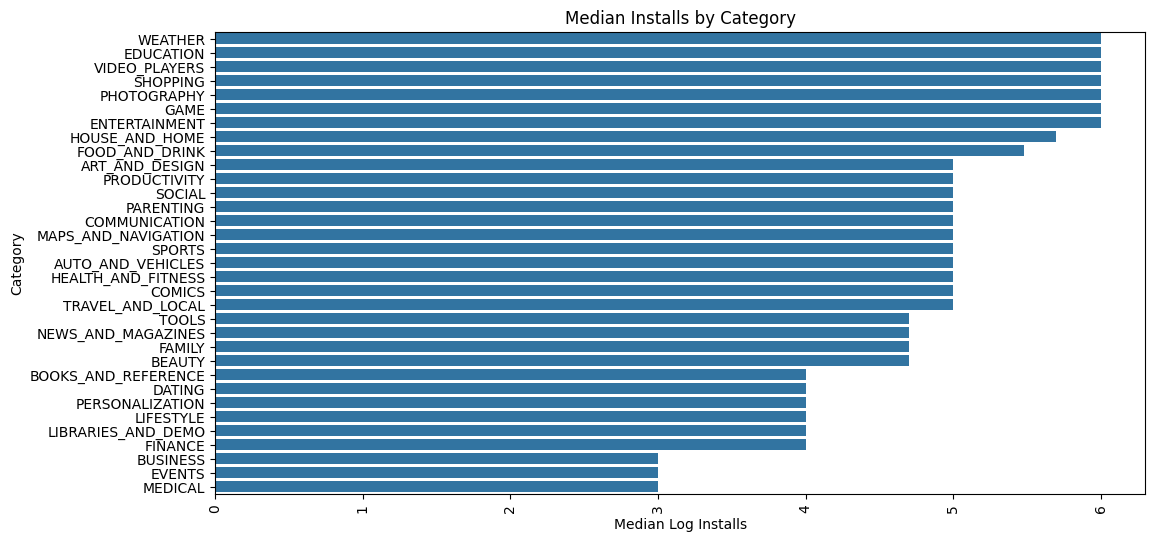

In [198]:
category_installs = (
    df.groupby("category")["installs"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    y=category_installs.index,
    x=np.log10(category_installs.values + 1)
)

plt.xticks(rotation=90)

plt.ylabel("Category")
plt.xlabel("Median Log Installs")
plt.title("Median Installs by Category")

plt.savefig(
    f"{config['output_data']['charts']}category_median_installs.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

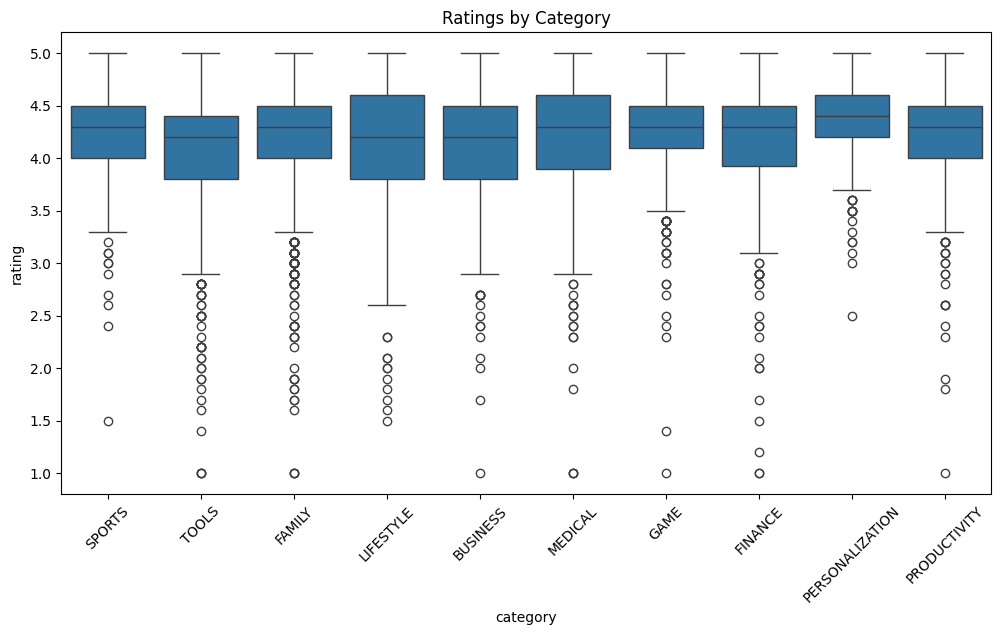

In [199]:
top_categories = (
    df["category"]
    .value_counts()
    .head(10)
    .index
)

top_df = df[df["category"].isin(top_categories)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=top_df,
    x="category",
    y="rating"
)

plt.xticks(rotation=45)

plt.title("Ratings by Category")

plt.savefig(
    f"{config['output_data']['charts']}category_ratings.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

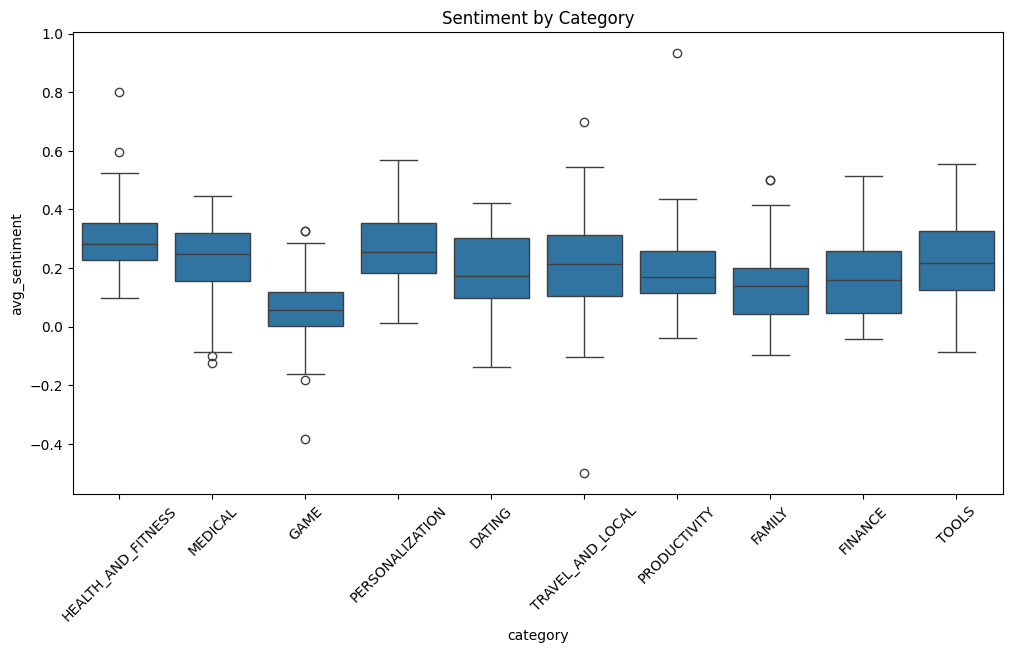

In [200]:
top_sentiment_categories = (
    sentiment_df["category"]
    .value_counts()
    .head(10)
    .index
)

top_sentiment_df = sentiment_df[
    sentiment_df["category"].isin(top_sentiment_categories)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=top_sentiment_df,
    x="category",
    y="avg_sentiment"
)

plt.xticks(rotation=45)

plt.title("Sentiment by Category")

plt.savefig(
    f"{config['output_data']['charts']}category_sentiment.png",
    # f"{config['output_data']['charts']}correlation_matrix_{timestamp}.png,"
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [201]:
# - Different app categories exhibit substantially different adoption patterns.
# - High-install categories do not necessarily achieve the strongest user sentiment.
# - Game apps generate relatively weaker sentiment despite maintaining competitive ratings, 
#   suggesting that star ratings may not fully capture user satisfaction.
# - Ratings and sentiment are related but not identical measures of user satisfaction.

In [202]:
# ==================================================================================================================================
# Correlation Analysis
# ==================================================================================================================================

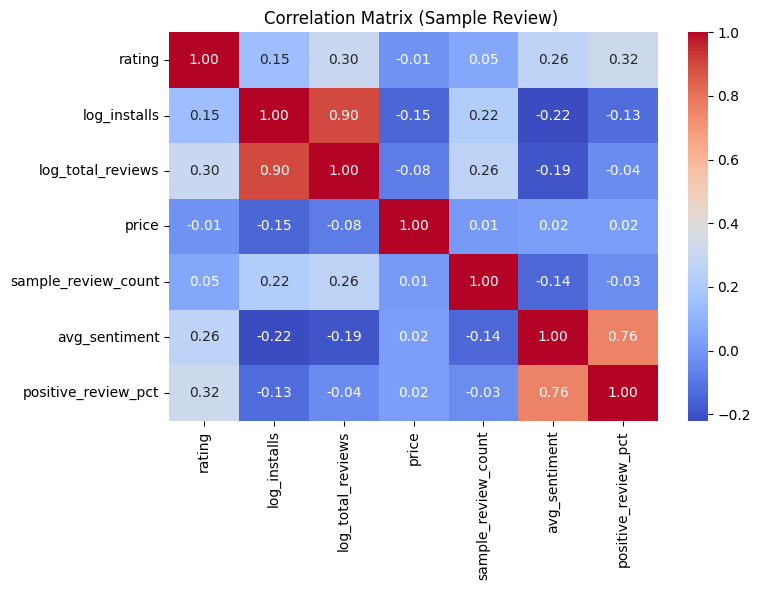

In [203]:
review_corr_df = sentiment_df[
    [
        "rating",
        "log_installs",
        "log_total_reviews",
        "price",
        "sample_review_count",
        "avg_sentiment",
        "positive_review_pct"
    ]
]

review_corr_matrix = review_corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    review_corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix (Sample Review) ")

plt.tight_layout()

# from datetime import datetime
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.savefig(
    f"{config['output_data']['charts']}correlation_matrix_sample_review.png",
    # f"{config['output_data']['charts']}correlation_matrix_{timestamp}.png,"
    dpi=300,
    bbox_inches='tight'
)

plt.show()


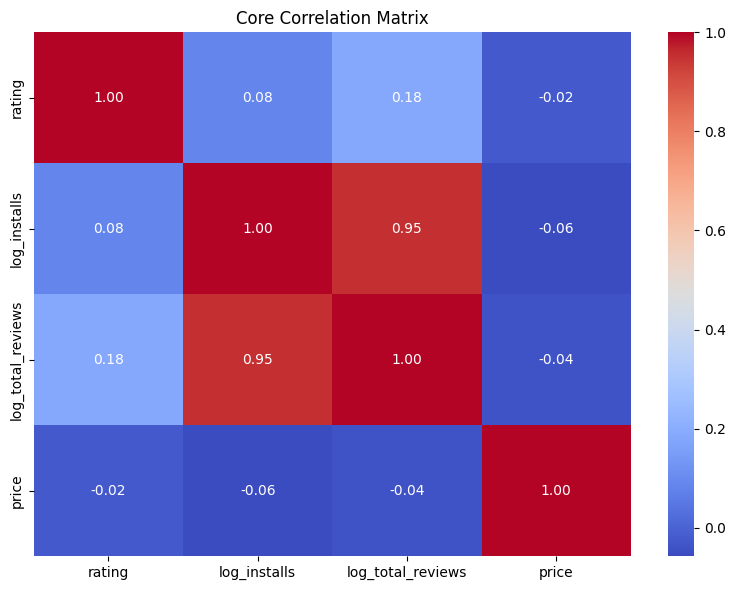

In [204]:
core_corr_df = df[
    [
        "rating",
        "log_installs",
        "log_total_reviews",
        "price"
    ]
]

core_corr_df = core_corr_df.dropna()

core_corr_matrix = core_corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    core_corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Core Correlation Matrix")

plt.tight_layout()

# from datetime import datetime
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.savefig(
    f"{config['output_data']['charts']}correlation_matrix_core.png",
    # f"{config['output_data']['charts']}correlation_matrix_{timestamp}.png,"
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [193]:
# Conclusion

In [194]:
# Recommendations/Next steps